# Audience Conversation Analysis

This notebook answers the research question:

*Do employer-branding videos generate more audience conversation than product- and technology-focused videos?*

It uses the clean datasets produced in the validation notebook and compares the two content categories on comments, views, likes, and normalized conversation intensity.


## Load The Clean Comparison Datasets

These datasets are the final outputs of `classification-validation.ipynb`, after ambiguous overlapping videos were removed.


In [120]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency, mannwhitneyu, t, wilcoxon

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

employee = pd.read_json("../data/employee-based-content-clean.json", lines=True)
product = pd.read_json("../data/product-based-content-clean.json", lines=True)

employee["content_type"] = "employer_branding"
product["content_type"] = "product_technology"

df = pd.concat([employee, product], ignore_index=True)

for column in ["views", "likes", "comments"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

published_at_ms = pd.to_datetime(df["publishedAt"], unit="ms", errors="coerce")
published_at_text = pd.to_datetime(df["publishedAt"], format="mixed", errors="coerce")
df["publishedAt"] = published_at_ms.fillna(published_at_text)
df["publication_year"] = df["publishedAt"].dt.year
df["company"] = df["company"].fillna("Unknown")

df["comments_per_1000_views"] = np.where(
    df["views"] > 0,
    df["comments"] / df["views"] * 1000,
    np.nan,
)
df["likes_per_1000_views"] = np.where(
    df["views"] > 0,
    df["likes"] / df["views"] * 1000,
    np.nan,
)
df["has_comments"] = (df["comments"].fillna(0) > 0).astype(int)

df.head()


,_id,channelId,company,title,description,tags,publishedAt,views,likes,comments,content_type,publication_year,comments_per_1000_views,likes_per_1000_views,has_comments
0,jiHmzKeqeT8,UCLAKVzA5WEadvys9CKOksQg,Adecco SA,Klåss Clerkx - CEO for One Month 2016 at Adecc...,The #CEO1Month selection process started with ...,"[CEO1MONTH, Adecco Way to Work, bootcamp]",2016-05-25 15:51:58,156,1.0000,0.0000,employer_branding,2016,0.0000,6.4103,0
1,1p9NjGCEieg,UCrSSdGg-aH_HgCHtsnoonIg,Adecco SA,Adecco Thailand WayToWork 2014,กะเทาะเปลือกเด็กจบใหม่ ครั้งที่ 2 กิจกรรมเพื่อ...,"[Way2WorkTh, AdeccoThailand, WayToWork, HRtwt,...",2014-04-30 11:10:20,1249,5.0000,1.0000,employer_branding,2014,0.8006,4.0032,1
2,bmvCxO3zvsQ,UCrSSdGg-aH_HgCHtsnoonIg,Adecco SA,Adecco Thailand Career Up - Marketing Jobs,How to Introduce Yourself in English for Marke...,"[Marketing, Adecco, Jobs Seeker, Jobs]",2011-09-23 03:24:05,4535,6.0000,3.0000,employer_branding,2011,0.6615,1.3230,1
3,IEhTfm7Ytq8,UCLAKVzA5WEadvys9CKOksQg,Adecco SA,360° video: experience badminton with Lianne Tan,"An Olympic athlete has a lot of competences,.....","[sport, work, 360, Lianne, Tan, adecco, waytow...",2016-03-20 07:19:52,518,0.0000,0.0000,employer_branding,2016,0.0000,0.0000,0
4,ioIfpfL-LUI,UCLAKVzA5WEadvys9CKOksQg,Adecco SA,Job: Van Gansewinkel zoekt chauffeurs m/v,Enkele jaren ervaring als chauffeur C of CE? Z...,"[chauffeur, job, vicancy, Van Gansewinkel, Ade...",2016-03-04 11:46:56,296,2.0000,0.0000,employer_branding,2016,0.0000,6.7568,0


## Dataset Overview

In [121]:
dataset_overview = pd.DataFrame(
    {
        "n_videos": df.groupby("content_type")["_id"].count(),
        "unique_companies": df.groupby("content_type")["company"].nunique(),
        "first_year": df.groupby("content_type")["publication_year"].min(),
        "last_year": df.groupby("content_type")["publication_year"].max(),
        "share_with_any_comments": df.groupby("content_type")["has_comments"].mean(),
    }
)

dataset_overview


,n_videos,unique_companies,first_year,last_year,share_with_any_comments
content_type,,,,,
employer_branding,2164,88,2007,2024,0.1691
product_technology,3649,106,2007,2016,0.2527


## Descriptive Statistics

In [122]:
descriptive_stats = df.groupby("content_type").agg(
    n_videos=("_id", "count"),
    comments_mean=("comments", "mean"),
    comments_median=("comments", "median"),
    comments_std=("comments", "std"),
    views_mean=("views", "mean"),
    views_median=("views", "median"),
    views_std=("views", "std"),
    likes_mean=("likes", "mean"),
    likes_median=("likes", "median"),
    likes_std=("likes", "std"),
    cpv_mean=("comments_per_1000_views", "mean"),
    cpv_median=("comments_per_1000_views", "median"),
    cpv_std=("comments_per_1000_views", "std"),
)

descriptive_stats


,n_videos,comments_mean,comments_median,comments_std,views_mean,views_median,views_std,likes_mean,likes_median,likes_std,cpv_mean,cpv_median,cpv_std
content_type,,,,,,,,,,,,,
employer_branding,2164,0.9978,0.0000,6.7877,"9,689.9358",569.5000,"102,994.1134",12.0453,2.0000,88.6902,0.3069,0.0000,1.7469
product_technology,3649,3.9333,0.0000,42.6206,"65,109.8833",999.0000,"486,176.1437",34.2246,2.0000,437.9237,0.3694,0.0000,1.8690


In [123]:
normalized_quantiles = (
    df.groupby("content_type")["comments_per_1000_views"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .unstack()
)

normalized_quantiles


,0.2500,0.5000,0.7500,0.9000,0.9500,0.9900
content_type,,,,,,
employer_branding,0.0000,0.0000,0.0000,0.6051,1.5021,6.0225
product_technology,0.0000,0.0000,0.0365,0.6632,1.7672,7.4034


## Distribution Plots

/var/folders/gg/w_x4b_tx7tqgntjvzj6vzb4w0000gn/T/ipykernel_10015/3717918970.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(box_data, labels=["employer_branding", "product_technology"], showfliers=False)


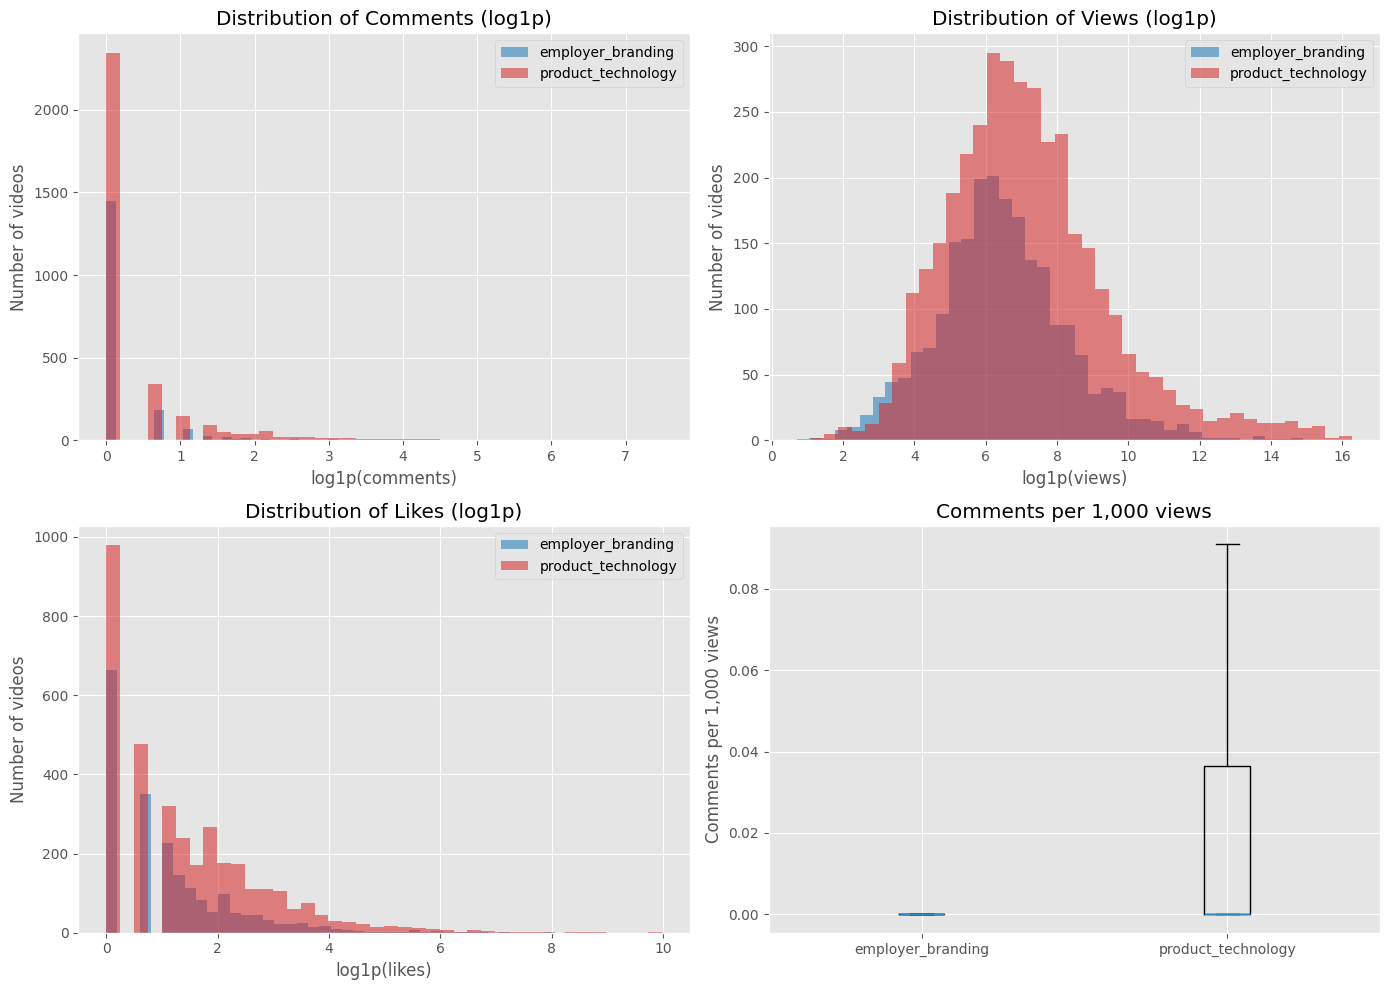

In [124]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_specs = [
    ("comments", "Comments", axes[0, 0]),
    ("views", "Views", axes[0, 1]),
    ("likes", "Likes", axes[1, 0]),
]

for variable, label, axis in plot_specs:
    for content_type, color in [("employer_branding", "#1f77b4"), ("product_technology", "#d62728")]:
        values = np.log1p(df.loc[df["content_type"] == content_type, variable].dropna())
        axis.hist(values, bins=40, alpha=0.55, label=content_type, color=color)
    axis.set_title(f"Distribution of {label} (log1p)")
    axis.set_xlabel(f"log1p({label.lower()})")
    axis.set_ylabel("Number of videos")
    axis.legend()

cpv_cap = df["comments_per_1000_views"].quantile(0.99)
box_data = [
    df.loc[df["content_type"] == "employer_branding", "comments_per_1000_views"].clip(upper=cpv_cap).dropna(),
    df.loc[df["content_type"] == "product_technology", "comments_per_1000_views"].clip(upper=cpv_cap).dropna(),
]
axes[1, 1].boxplot(box_data, labels=["employer_branding", "product_technology"], showfliers=False)
axes[1, 1].set_title("Comments per 1,000 views")
axes[1, 1].set_ylabel("Comments per 1,000 views")

plt.tight_layout()
plt.show()


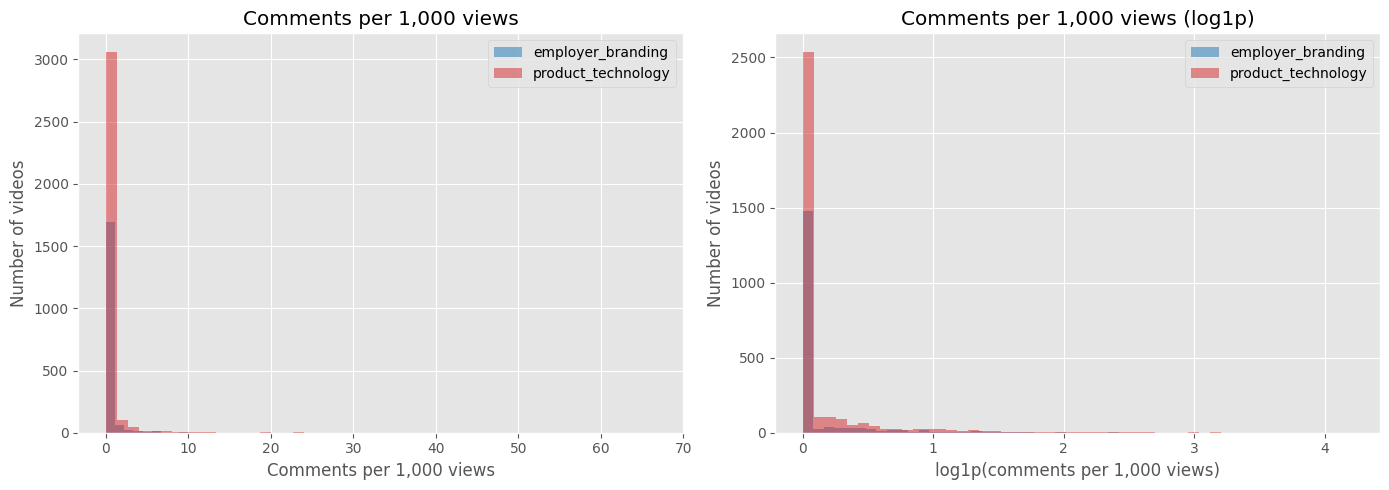

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for content_type, color in [("employer_branding", "#1f77b4"), ("product_technology", "#d62728")]:
    subset = df.loc[df["content_type"] == content_type, "comments_per_1000_views"].dropna()
    axes[0].hist(subset, bins=50, alpha=0.5, label=content_type, color=color)
    axes[1].hist(np.log1p(subset), bins=50, alpha=0.5, label=content_type, color=color)

axes[0].set_title("Comments per 1,000 views")
axes[0].set_xlabel("Comments per 1,000 views")
axes[0].set_ylabel("Number of videos")
axes[0].legend()

axes[1].set_title("Comments per 1,000 views (log1p)")
axes[1].set_xlabel("log1p(comments per 1,000 views)")
axes[1].set_ylabel("Number of videos")
axes[1].legend()

plt.tight_layout()
plt.show()


## Statistical Tests

In [126]:
test_rows = []

for variable in ["comments", "views", "likes", "comments_per_1000_views"]:
    employer_values = df.loc[df["content_type"] == "employer_branding", variable].dropna()
    product_values = df.loc[df["content_type"] == "product_technology", variable].dropna()
    statistic, p_value = mannwhitneyu(employer_values, product_values, alternative="two-sided")
    test_rows.append(
        {
            "variable": variable,
            "employer_mean": employer_values.mean(),
            "product_mean": product_values.mean(),
            "employer_median": employer_values.median(),
            "product_median": product_values.median(),
            "mannwhitney_u": statistic,
            "p_value": p_value,
        }
    )

test_results = pd.DataFrame(test_rows)
test_results


,variable,employer_mean,product_mean,employer_median,product_median,mannwhitney_u,p_value
0,comments,0.9978,3.9333,0.0000,0.0000,"2,691,989.5000",0.0000
1,views,"9,689.9358","65,109.8833",569.5000,999.0000,"3,274,252.0000",0.0000
2,likes,12.0453,34.2246,2.0000,2.0000,"3,171,666.5000",0.0000
3,comments_per_1000_views,0.3069,0.3694,0.0000,0.0000,"2,754,513.0000",0.0000


In [127]:
comment_presence_table = pd.crosstab(df["content_type"], df["has_comments"])
chi2_result = chi2_contingency(comment_presence_table)

comment_presence_table, chi2_result


(has_comments           0    1
 content_type                 
 employer_branding   1798  366
 product_technology  2727  922,
 Chi2ContingencyResult(statistic=54.48263001867953, pvalue=1.5682791893263042e-13, dof=1, expected_freq=array([[1684.51746086,  479.48253914],
        [2840.48253914,  808.51746086]])))

## Regression Controls

To test whether the relationship remains after accounting for company and publication year, the notebook estimates fixed-effects style OLS models using dummy variables for company and year.


In [128]:
def fit_ols(X, y):
    xtx = X.T @ X
    xtx_inv = np.linalg.pinv(xtx)
    beta = xtx_inv @ X.T @ y
    residuals = y - X @ beta
    n_obs, n_params = X.shape
    sigma2 = (residuals @ residuals) / (n_obs - n_params)
    vcov = sigma2 * xtx_inv
    std_errors = np.sqrt(np.diag(vcov))
    t_values = beta / std_errors
    p_values = 2 * t.sf(np.abs(t_values), df=n_obs - n_params)
    return beta, std_errors, p_values, residuals, n_obs, n_params


def fixed_effect_design(data, predictors, fixed_effect_columns):
    pieces = [pd.DataFrame({"intercept": np.ones(len(data))}, index=data.index)]

    for predictor in predictors:
        pieces.append(pd.DataFrame({predictor: data[predictor].astype(float)}, index=data.index))

    for fixed_effect in fixed_effect_columns:
        dummies = pd.get_dummies(data[fixed_effect], prefix=fixed_effect, drop_first=True, dtype=float)
        pieces.append(dummies)

    return pd.concat(pieces, axis=1)


In [129]:
model_cpv = df.dropna(subset=["comments_per_1000_views", "publication_year"]).copy()
model_cpv["is_employer_branding"] = (model_cpv["content_type"] == "employer_branding").astype(int)
model_cpv["log_comments_per_1000_views"] = np.log1p(model_cpv["comments_per_1000_views"])

X_cpv = fixed_effect_design(
    model_cpv,
    predictors=["is_employer_branding"],
    fixed_effect_columns=["company", "publication_year"],
)
y_cpv = model_cpv["log_comments_per_1000_views"].to_numpy(dtype=float)

beta_cpv, se_cpv, p_cpv, resid_cpv, n_cpv, k_cpv = fit_ols(X_cpv.to_numpy(dtype=float), y_cpv)
idx_cpv = list(X_cpv.columns).index("is_employer_branding")

cpv_model_summary = pd.DataFrame(
    {
        "coefficient": [beta_cpv[idx_cpv]],
        "std_error": [se_cpv[idx_cpv]],
        "p_value": [p_cpv[idx_cpv]],
        "percent_effect_approx": [np.expm1(beta_cpv[idx_cpv]) * 100],
        "n_obs": [n_cpv],
        "n_params": [k_cpv],
    },
    index=["is_employer_branding"],
)

cpv_model_summary


,coefficient,std_error,p_value,percent_effect_approx,n_obs,n_params
is_employer_branding,-0.0062,0.0148,0.6729,-0.6211,5080,121


In [130]:
model_comments = df.dropna(subset=["comments", "views", "likes", "publication_year"]).copy()
model_comments["is_employer_branding"] = (model_comments["content_type"] == "employer_branding").astype(int)
model_comments["log_comments"] = np.log1p(model_comments["comments"].clip(lower=0))
model_comments["log_views"] = np.log1p(model_comments["views"].clip(lower=0))
model_comments["log_likes"] = np.log1p(model_comments["likes"].clip(lower=0))

X_comments = fixed_effect_design(
    model_comments,
    predictors=["is_employer_branding", "log_views", "log_likes"],
    fixed_effect_columns=["company", "publication_year"],
)
y_comments = model_comments["log_comments"].to_numpy(dtype=float)

beta_comments, se_comments, p_comments, resid_comments, n_comments, k_comments = fit_ols(
    X_comments.to_numpy(dtype=float), y_comments
)
idx_comments = list(X_comments.columns).index("is_employer_branding")

comment_model_summary = pd.DataFrame(
    {
        "coefficient": [beta_comments[idx_comments]],
        "std_error": [se_comments[idx_comments]],
        "p_value": [p_comments[idx_comments]],
        "percent_effect_approx": [np.expm1(beta_comments[idx_comments]) * 100],
        "n_obs": [n_comments],
        "n_params": [k_comments],
    },
    index=["is_employer_branding"],
)

comment_model_summary


,coefficient,std_error,p_value,percent_effect_approx,n_obs,n_params
is_employer_branding,-0.0061,0.0200,0.7598,-0.6106,5028,121


## Company-Year Robustness Check

This stricter comparison tests whether the relative conversation level is similar when the two content types are compared within the same company and publication year.


In [131]:
company_year_summary = (
    df.groupby(["company", "publication_year", "content_type"])
    .agg(
        videos=("_id", "count"),
        mean_comments_per_1000_views=("comments_per_1000_views", "mean"),
        median_comments_per_1000_views=("comments_per_1000_views", "median"),
    )
    .reset_index()
)

paired_company_year = company_year_summary.pivot_table(
    index=["company", "publication_year"],
    columns="content_type",
    values=["videos", "mean_comments_per_1000_views", "median_comments_per_1000_views"],
)

paired_company_year.columns = [
    "_".join(parts).strip() for parts in paired_company_year.columns.to_flat_index()
]

paired_company_year = paired_company_year.dropna(
    subset=["mean_comments_per_1000_views_employer_branding", "mean_comments_per_1000_views_product_technology"]
)

paired_company_year.head()


mean_comments_per_1000_views_employer_branding  \
company publication_year                                                   
ABB Ltd 2010                                                      0.2199   
        2011                                                      0.0231   
        2012                                                      0.0554   
        2013                                                      0.0000   
        2014                                                      0.1061   

                          mean_comments_per_1000_views_product_technology  \
company publication_year                                                    
ABB Ltd 2010                                                       0.2209   
        2011                                                       0.2066   
        2012                                                       0.2248   
        2013                                                       0.2380   
        2014                                                       0.2979   

                          median_comments_per_1000_views_employer_branding  \
company publication_year                                                     
ABB Ltd 2010                                                        0.2199   
        2011                                                        0.0000   
        2012                                                        0.0000   
        2013                                                        0.0000   
        2014                                                        0.0000   

                          median_comments_per_1000_views_product_technology  \
company publication_year                                                      
ABB Ltd 2010                                                         0.1889   
        2011                                                         0.0000   
        2012                                                         0.0000   
        2013                                                         0.0646   
        2014                                                         0.0000   

                          videos_employer_branding  videos_product_technology  
company publication_year                                                       
ABB Ltd 2010                                2.0000                     8.0000  
        2011                                6.0000                    34.0000  
        2012                               30.0000                    59.0000  
        2013                                4.0000                    60.0000  
        2014                                5.0000                    71.0000

In [132]:
paired_difference = (
    paired_company_year["mean_comments_per_1000_views_employer_branding"]
    - paired_company_year["mean_comments_per_1000_views_product_technology"]
)

nonzero_differences = paired_difference[paired_difference != 0]
wilcoxon_result = wilcoxon(nonzero_differences)

paired_summary = pd.DataFrame(
    {
        "paired_company_year_cells": [len(paired_company_year)],
        "nonzero_difference_cells": [len(nonzero_differences)],
        "mean_difference_employer_minus_product": [paired_difference.mean()],
        "median_difference_employer_minus_product": [paired_difference.median()],
        "share_of_cells_where_employer_is_higher": [(paired_difference > 0).mean()],
        "wilcoxon_p_value": [wilcoxon_result.pvalue],
    }
)

paired_summary


,paired_company_year_cells,nonzero_difference_cells,mean_difference_employer_minus_product,median_difference_employer_minus_product,share_of_cells_where_employer_is_higher,wilcoxon_p_value
0,180,126,0.0673,0.0000,0.3000,0.9583


## Conclusion

In [133]:
employer_stats = descriptive_stats.loc["employer_branding"]
product_stats = descriptive_stats.loc["product_technology"]

cpv_test_p = test_results.loc[
    test_results["variable"] == "comments_per_1000_views", "p_value"
].iloc[0]

comments_test_p = test_results.loc[
    test_results["variable"] == "comments", "p_value"
].iloc[0]

conclusion_lines = [
    "Research question: Do employer-branding videos generate more audience conversation than product- and technology-focused videos?",
    "",
    f"- Raw comments are lower for employer-branding videos (mean {employer_stats['comments_mean']:.3f}) than for product-technology videos (mean {product_stats['comments_mean']:.3f}).",
    f"- Normalized conversation is also slightly lower for employer-branding videos (mean {employer_stats['cpv_mean']:.3f} comments per 1,000 views) than for product-technology videos (mean {product_stats['cpv_mean']:.3f}).",
    f"- The Mann-Whitney test finds a significant distributional difference for raw comments (p = {comments_test_p:.4g}) and for comments per 1,000 views (p = {cpv_test_p:.4g}), but the direction does not support the employer-branding hypothesis.",
    f"- The share of videos with at least one comment is {dataset_overview.loc['employer_branding', 'share_with_any_comments']:.3f} for employer-branding videos and {dataset_overview.loc['product_technology', 'share_with_any_comments']:.3f} for product-technology videos.",
    f"- After controlling for company and publication year, the employer-branding coefficient is {cpv_model_summary.loc['is_employer_branding', 'coefficient']:.4f} (p = {cpv_model_summary.loc['is_employer_branding', 'p_value']:.4g}) for normalized conversation.",
    f"- In the raw-comment model that also controls for views and likes, the employer-branding coefficient is {comment_model_summary.loc['is_employer_branding', 'coefficient']:.4f} (p = {comment_model_summary.loc['is_employer_branding', 'p_value']:.4g}).",
    f"- The company-year robustness check yields a Wilcoxon p-value of {paired_summary.loc[0, 'wilcoxon_p_value']:.4g}.",
    "",
    "Conclusion: this dataset does not provide evidence that employer-branding videos are associated with higher audience conversation. If anything, product-technology videos receive slightly more conversation on both absolute and normalized measures, and that pattern does not reverse once company and publication year are taken into account.",
]

print("\n".join(conclusion_lines))


Research question: Do employer-branding videos generate more audience conversation than product- and technology-focused videos?

- Raw comments are lower for employer-branding videos (mean 0.998) than for product-technology videos (mean 3.933).
- Normalized conversation is also slightly lower for employer-branding videos (mean 0.307 comments per 1,000 views) than for product-technology videos (mean 0.369).
- The Mann-Whitney test finds a significant distributional difference for raw comments (p = 2.041e-12) and for comments per 1,000 views (p = 7.017e-08), but the direction does not support the employer-branding hypothesis.
- The share of videos with at least one comment is 0.169 for employer-branding videos and 0.253 for product-technology videos.
- After controlling for company and publication year, the employer-branding coefficient is -0.0062 (p = 0.6729) for normalized conversation.
- In the raw-comment model that also controls for views and likes, the employer-branding coefficient